成功处理 548 个分子，无效SMILES数量：2


F:\anaconda\envs\mordred-fixed-env\lib\site-packages\torch_geometric\deprecation.py:12: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 050 | Train Loss: 0.2570 | Val Loss: 0.5513
Epoch 100 | Train Loss: 0.1806 | Val Loss: 0.3751
Epoch 150 | Train Loss: 0.1784 | Val Loss: 0.5300
Epoch 200 | Train Loss: 0.1602 | Val Loss: 0.3544
Epoch 250 | Train Loss: 0.1224 | Val Loss: 0.3088
Epoch 300 | Train Loss: 0.1082 | Val Loss: 0.2888
Epoch 350 | Train Loss: 0.0924 | Val Loss: 0.3118
Epoch 400 | Train Loss: 0.1018 | Val Loss: 0.2849
Epoch 450 | Train Loss: 0.0858 | Val Loss: 0.2824
Epoch 500 | Train Loss: 0.0819 | Val Loss: 0.2954
Epoch 550 | Train Loss: 0.0821 | Val Loss: 0.2858
Epoch 600 | Train Loss: 0.0905 | Val Loss: 0.2885
Epoch 650 | Train Loss: 0.0675 | Val Loss: 0.2853
Epoch 700 | Train Loss: 0.0920 | Val Loss: 0.2827
Epoch 750 | Train Loss: 0.0758 | Val Loss: 0.2832
Epoch 800 | Train Loss: 0.0824 | Val Loss: 0.2832
Early stopping at epoch 833

训练集 RMSE: 0.6130 R²: 0.9594
验证集 RMSE: 1.5371 R²: 0.6982
测试集 RMSE: 1.5639 R²: 0.7853


C:\Users\Hanchong YU\AppData\Local\Temp\ipykernel_118688\436694860.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_baseline_mode

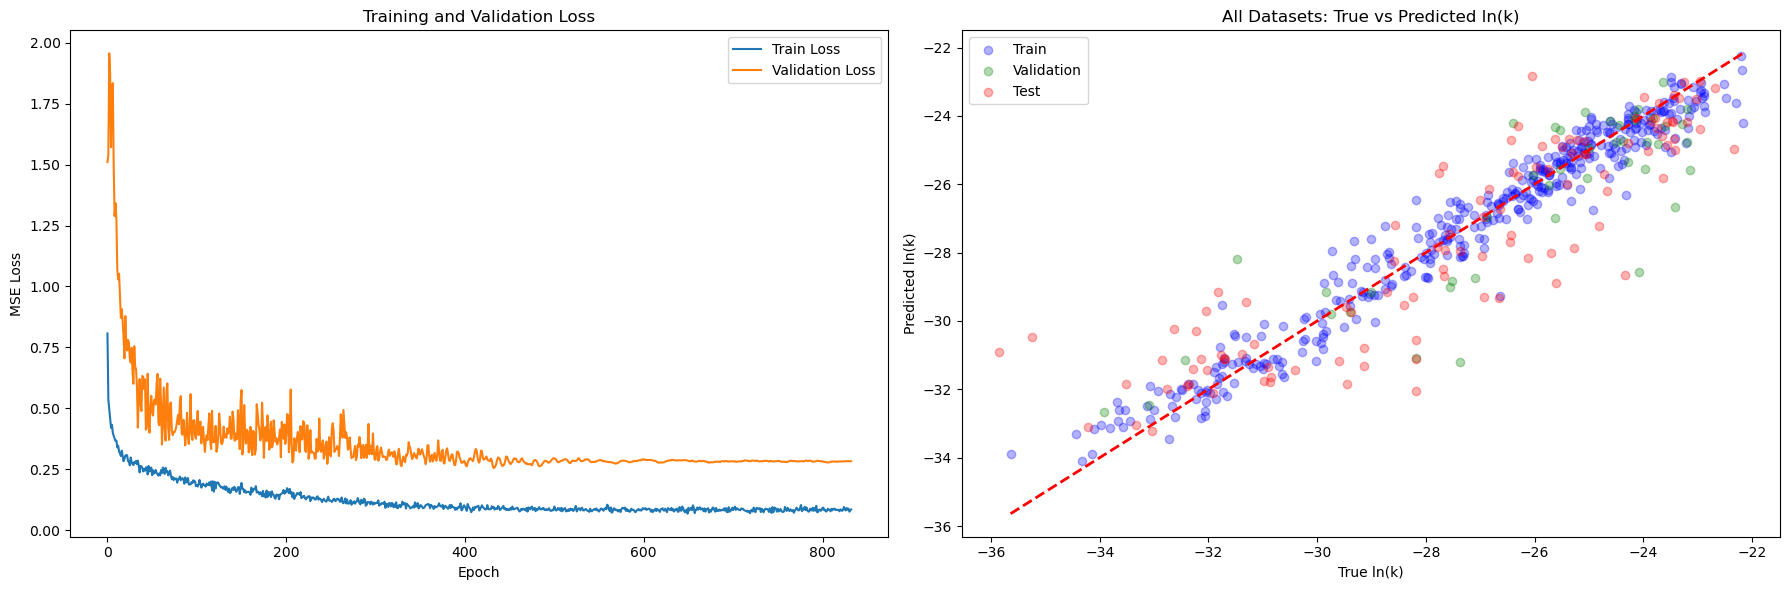

In [2]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def load_and_process_data(file_path, target_col='ln_k0'):
    if file_path.endswith('.csv'):
        df = pd.read_csv(file_path)
    else:
        df = pd.read_excel(file_path)
        
    df = df.dropna(subset=['Smiles', target_col])

    def get_base_atom_features(atom):
        return [
            float(atom.GetAtomicNum()),
            float(atom.GetDegree()),
            float(atom.GetFormalCharge()),
            float(atom.GetTotalNumHs()),
            float(atom.IsInRing()),
            float(atom.GetIsAromatic())
        ]

    data_list = []
    invalid_smiles = []
    
    for idx, row in df.iterrows():
        smiles = row['Smiles']
        ln_k = row[target_col]
        
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                raise ValueError('Invalid SMILES')
            
            mol = Chem.AddHs(mol)

            if AllChem.EmbedMolecule(mol, randomSeed=42, enforceChirality=True) != 0:
                AllChem.EmbedMolecule(mol, randomSeed=42, useRandomCoords=True)
            
            try:
                AllChem.MMFFOptimizeMolecule(mol)
            except Exception:
                pass 
                
            conf = mol.GetConformer()
            
            atom_features = []
            for i, atom in enumerate(mol.GetAtoms()):
                features = get_base_atom_features(atom)

                pos = conf.GetAtomPosition(i)
                features.extend([pos.x, pos.y, pos.z])
                atom_features.append(features)
            
            edge_index = []
            for bond in mol.GetBonds():
                i = bond.GetBeginAtomIdx()
                j = bond.GetEndAtomIdx()
                edge_index.extend([(i, j), (j, i)])
                
            edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
            
            data = Data(
                x=torch.tensor(atom_features, dtype=torch.float),
                edge_index=edge_index,
                y=torch.tensor([ln_k], dtype=torch.float)
            )
            data_list.append(data)
        except Exception:
            invalid_smiles.append(smiles)
            continue
            
    print(f"成功处理 {len(data_list)} 个分子，无效SMILES数量：{len(invalid_smiles)}")
    return data_list

class DirectGCN(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, hidden_dim2=64):
        super(DirectGCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim*2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim*2, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)
        
        x = global_mean_pool(x, batch)
        x = self.fc(x)
        return x.squeeze(-1)

def evaluate_model(loader, model, scaler_lnk):
    model.eval()
    lnk_true = []
    lnk_pred = []
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred_lnk = model(batch)
            
            pred_np = pred_lnk.cpu().numpy().reshape(-1, 1)
            true_np = batch.y.cpu().numpy().reshape(-1, 1)
            
            pred_orig = scaler_lnk.inverse_transform(pred_np)
            true_orig = scaler_lnk.inverse_transform(true_np)
            
            lnk_true.append(true_orig)
            lnk_pred.append(pred_orig)
            
    lnk_true = np.vstack(lnk_true)
    lnk_pred = np.vstack(lnk_pred)
    
    metrics = {
        'rmse': np.sqrt(mean_squared_error(lnk_true, lnk_pred)),
        'r2': r2_score(lnk_true, lnk_pred)
    }
    return metrics, lnk_true, lnk_pred

if __name__ == '__main__':
    file_path = "GNN_ABn_TEMP.csv"  #Change to file path
    dataset = load_and_process_data(file_path, target_col='ln_k0')
    
    train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)
    train_data, val_data = train_test_split(train_data, test_size=0.1, random_state=42)

    scaler_lnk = StandardScaler()
    train_lnk = np.array([data.y.item() for data in train_data]).reshape(-1, 1)
    scaler_lnk.fit(train_lnk)

    def apply_scaling(data_list):
        for data in data_list:
            scaled_lnk = (data.y.numpy() - scaler_lnk.mean_[0]) / scaler_lnk.scale_[0]
            data.y = torch.tensor(scaled_lnk, dtype=torch.float)

    apply_scaling(train_data)
    apply_scaling(val_data)
    apply_scaling(test_data)

    batch_size = 256
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size)
    test_loader = DataLoader(test_data, batch_size=batch_size)

    input_dim = dataset[0].x.shape[1]
    model = DirectGCN(input_dim=input_dim).to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=50, factor=0.5)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience = 400
    patience_counter = 0
    
    for epoch in range(2000):
        model.train()
        epoch_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            
            pred_lnk = model(batch)
            true_lnk = batch.y.view(-1)
            
            loss = criterion(pred_lnk, true_lnk)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * batch.num_graphs

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                pred_lnk = model(batch)
                true_lnk = batch.y.view(-1)
                loss = criterion(pred_lnk, true_lnk)
                val_loss += loss.item() * batch.num_graphs

        train_loss = epoch_loss / len(train_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)
        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_baseline_model.pth')
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

        if (epoch+1) % 50 == 0:
            print(f'Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    model.load_state_dict(torch.load('best_baseline_model.pth'))
    
    train_metrics, train_true, train_pred = evaluate_model(train_loader, model, scaler_lnk)
    val_metrics, val_true, val_pred = evaluate_model(val_loader, model, scaler_lnk)
    test_metrics, test_true, test_pred = evaluate_model(test_loader, model, scaler_lnk)

    print('\n' + '='*50)
    print(f"训练集 RMSE: {train_metrics['rmse']:.4f} R²: {train_metrics['r2']:.4f}")
    print(f"验证集 RMSE: {val_metrics['rmse']:.4f} R²: {val_metrics['r2']:.4f}")
    print(f"测试集 RMSE: {test_metrics['rmse']:.4f} R²: {test_metrics['r2']:.4f}")
    print('='*50)

    plt.figure(figsize=(18, 6))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.title('Training and Validation Loss')

    plt.subplot(1, 2, 2)
    plt.scatter(train_true, train_pred, alpha=0.3, label='Train', color='blue')
    plt.scatter(val_true, val_pred, alpha=0.3, label='Validation', color='green')
    plt.scatter(test_true, test_pred, alpha=0.3, label='Test', color='red')
    
    min_val = min(np.min(train_true), np.min(train_pred))
    max_val = max(np.max(train_true), np.max(train_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    plt.xlabel('True ln(k)')
    plt.ylabel('Predicted ln(k)')
    plt.title('All Datasets: True vs Predicted ln(k)')
    plt.legend()
    plt.tight_layout()
    plt.show()